# Seasonal-Trend decomposition using LOESS (STL)

This notebook introduces **STL** — a classical procedure that splits a
univariate series into three additive pieces

$$
y_t = S_t + T_t + R_t,
$$

where $S_t$ is seasonal, $T_t$ is trend-cycle, and $R_t$ is the remainder.
Smoothing is performed with **LOESS** (locally weighted regression), which
gives STL more flexibility than moving-average classical decomposition.

**Reference**

> R. B. Cleveland, W. S. Cleveland, J. E. McRae, I. Terpenning.  
> *STL: A Seasonal-Trend Decomposition Procedure Based on Loess.*  
> Journal of Official Statistics, 6:3–73, 1990.

The implementation used below is the pure-NumPy / SciPy version shipped with
**PySDKit** (`pysdkit.tsa.STL`). It does **not** depend on Statsmodels.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import STL
from pysdkit.data import generate_time_series

print(STL(period=12))


Seasonal-Trend decomposition using LOESS (STL)


## 2. Algorithm principles

### 2.1 Inner loop (seasonal ↔ trend)

For a chosen period $n_p$ (e.g. 12 for monthly / yearly seasonality), one
inner iteration does:

1. **Detrend** — $y_t - \hat T_t$.
2. **Cycle-subseries LOESS** — smooth each seasonal position
   $\{y_j, y_{j+n_p}, \ldots\}$ with window `seasonal` (odd, ≥ 3).
3. **Low-pass filter** — three moving averages of lengths
   $(n_p,\, n_p,\, 3)$ followed by LOESS of length `low_pass`, then subtract
   from the temporary seasonal so that $S_t$ has no trend leakage.
4. **Deseasonalize** — $y_t - \hat S_t$.
5. **Trend LOESS** — smooth with window `trend` (odd, typically
   $\approx 1.5\, n_p\,/\,(1-1.5/\texttt{seasonal})$).

### 2.2 Outer loop (robust weights)

With `robust=True`, residuals update **bisquare** robustness weights and the
inner loop is repeated.  Large outliers receive near-zero weight so they do
not distort $S_t$ or $T_t$.

### 2.3 Main knobs

| Parameter | Role |
| --- | --- |
| `period` | Seasonal period $n_p$ |
| `seasonal` | Seasonal LOESS window (odd; 7 is the common default) |
| `trend` | Trend LOESS window (odd, $> n_p$) |
| `low_pass` | Low-pass LOESS window (odd, $\ge n_p$) |
| `robust` | Enable outer robustness iterations |

## 3. Synthetic monthly-style series

We build a length-240 series with period 12, a linear trend, and mild noise.

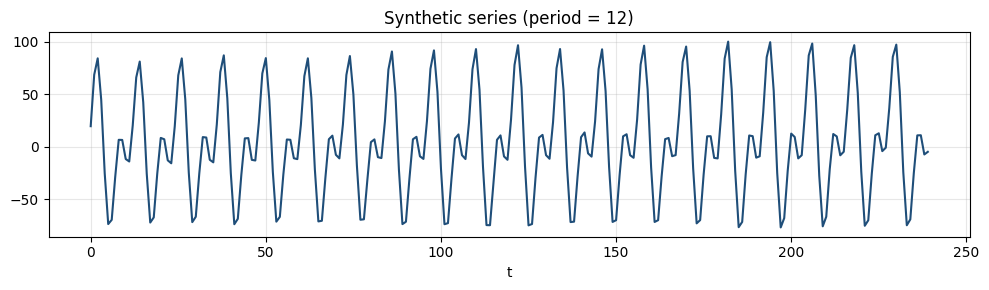

In [2]:
period = 12
n = 240
seasonal = generate_time_series(
    duration=n,
    periodicities=np.array([period]),
    num_harmonics=np.array([2]),
    std=np.array([0.4]),
    seed=0,
)
trend = np.linspace(0, 8, n)
y = seasonal + trend

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(y, color="#1f4e79")
ax.set_title("Synthetic series (period = 12)")
ax.set_xlabel("t")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 Fit STL

PySDKit uses the same scikit-learn-style pattern as the rest of the library:

In [3]:
stl = STL(period=period, seasonal=13)
res = stl.fit_transform(y)

print("observed:", res.observed.shape)
print("seasonal:", res.seasonal.shape)
print("trend:   ", res.trend.shape)
print("resid:   ", res.resid.shape)
print(
    "max |reconstruction error|:",
    np.max(np.abs(res.observed - (res.seasonal + res.trend + res.resid))),
)

observed: (240,)
seasonal: (240,)
trend:    (240,)
resid:    (240,)
max |reconstruction error|: 1.4210854715202004e-14


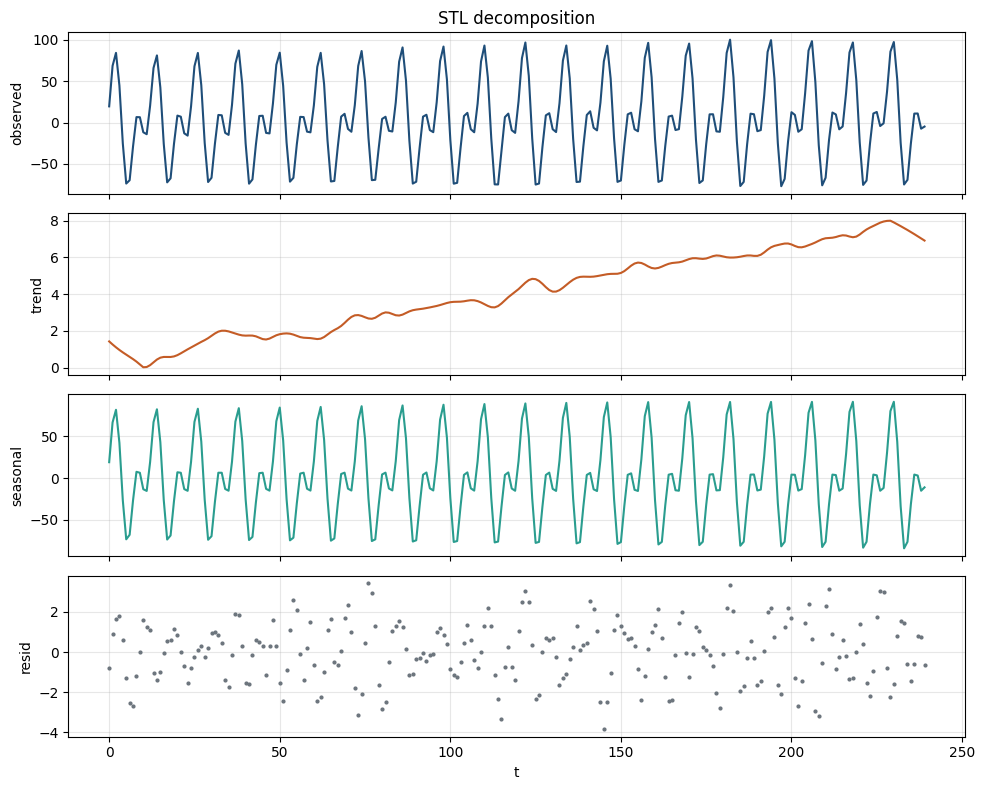

In [4]:
def plot_stl(result, title="STL decomposition"):
    comps = [
        ("observed", result.observed),
        ("trend", result.trend),
        ("seasonal", result.seasonal),
        ("resid", result.resid),
    ]
    fig, axes = plt.subplots(len(comps), 1, figsize=(10, 8), sharex=True)
    colors = ["#1f4e79", "#c45c26", "#2a9d8f", "#6c757d"]
    for ax, (name, series), c in zip(axes, comps, colors):
        if name == "resid":
            ax.plot(series, marker="o", ms=2, ls="none", color=c)
        else:
            ax.plot(series, color=c)
        ax.set_ylabel(name)
        ax.grid(True, alpha=0.3)
    axes[0].set_title(title)
    axes[-1].set_xlabel("t")
    plt.tight_layout()
    return fig


plot_stl(res)
plt.show()

### 3.2 Trend recovery

The extracted trend should track the planted linear drift closely.

corr(trend_hat, true_trend) = 0.9906


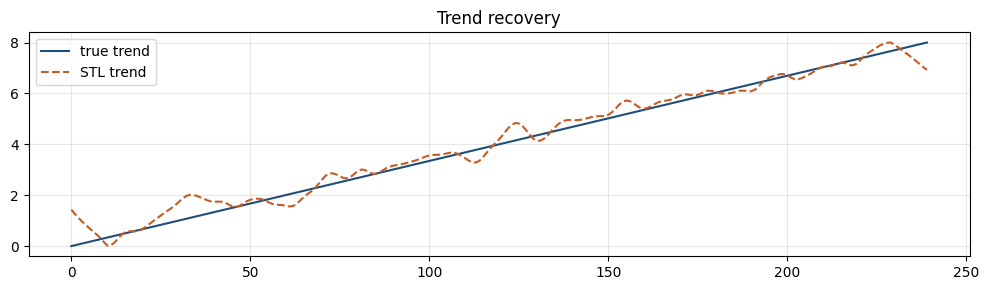

In [5]:
corr = np.corrcoef(res.trend, trend)[0, 1]
print(f"corr(trend_hat, true_trend) = {corr:.4f}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(trend, color="#1f4e79", label="true trend")
ax.plot(res.trend, color="#c45c26", ls="--", label="STL trend")
ax.legend()
ax.set_title("Trend recovery")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Robust vs non-robust STL

Inject a few large spikes.  Robust STL down-weights them; the non-robust fit
lets outliers leak into the seasonal / trend estimates.

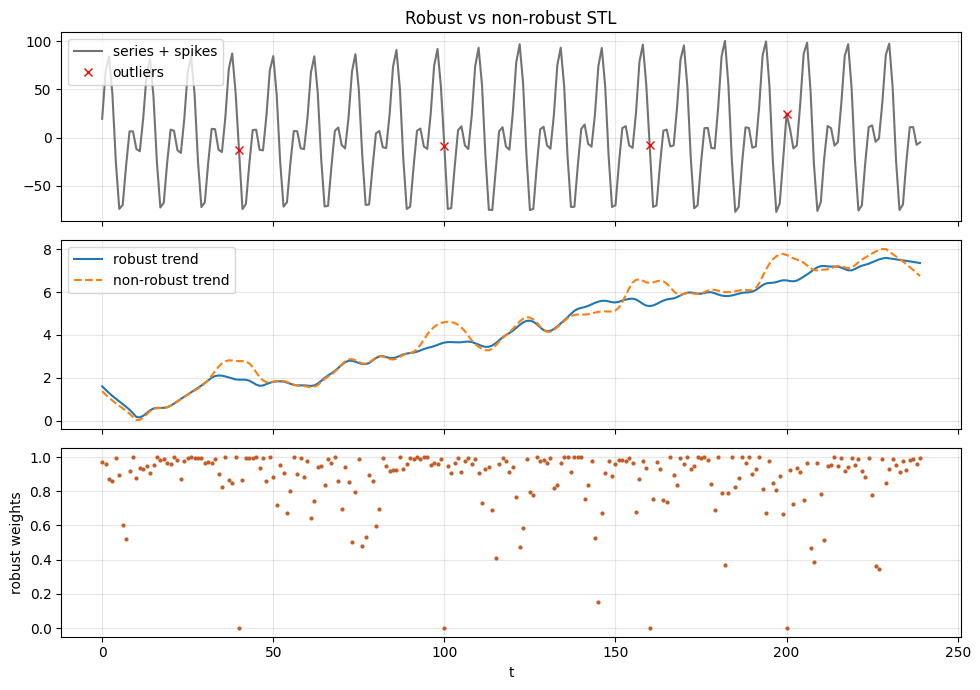

In [6]:
y_out = y.copy()
spike_idx = [40, 100, 160, 200]
y_out[spike_idx] += 12.0

res_rob = STL(period=period, seasonal=13, robust=True).fit_transform(y_out)
res_nrob = STL(period=period, seasonal=13, robust=False).fit_transform(y_out)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(y_out, color="0.45", label="series + spikes")
axes[0].plot(spike_idx, y_out[spike_idx], "rx", label="outliers")
axes[0].legend(loc="upper left")
axes[0].set_title("Robust vs non-robust STL")

axes[1].plot(res_rob.trend, label="robust trend")
axes[1].plot(res_nrob.trend, ls="--", label="non-robust trend")
axes[1].legend(loc="upper left")

axes[2].plot(res_rob.weights, marker="o", ms=2, ls="none", color="#c45c26")
axes[2].set_ylabel("robust weights")
axes[2].set_xlabel("t")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. API summary

```python
from pysdkit import STL

stl = STL(period=12, seasonal=13, robust=False)
res = stl.fit_transform(y)   # or stl(y)
# res.observed, res.seasonal, res.trend, res.resid, res.weights
```

## 6. Takeaways

- STL is an additive seasonal-trend decomposition driven by LOESS.
- Tune `seasonal` / `trend` for smoother or more flexible components.
- Use `robust=True` when the series contains spikes or level shifts.
- For **several** seasonal periods on one series, see the companion notebook
  `mstl.ipynb`.